# Singular Spectrum Analysis (SSA)

This notebook performs SSA on `daily.xlsx`, extracts trend, seasonality, and noise respectively, and forecasts the next 30 days.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Load the data
df = pd.read_excel('daily.xlsx', header=None, names=['Date', 'Value'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Data loaded successfully:")
print(df.head())

Data loaded successfully:
        Date  Value
0 2023-01-01      0
1 2023-01-02      0
2 2023-01-03      0
3 2023-01-04      0
4 2023-01-05   5780


## SSA Class Definition
Here we implement a robust SSA algorithm using numpy SVD, implementing Embedding, Reconstruction, and Forecasting via Linear Recurrent Formula (LRF).

In [5]:
class SSA:
    def __init__(self, tseries, L):
        # Time series and Window Length L
        self.tseries = np.array(tseries)
        self.N = len(self.tseries)
        self.L = L
        self.K = self.N - self.L + 1
        
        # Step 1: Embedding (Trajectory Matrix)
        self.X = np.column_stack([self.tseries[i:i+self.L] for i in range(self.K)])
        
        # Step 2: Singular Value Decomposition (SVD)
        self.U, self.Sigma, self.VT = np.linalg.svd(self.X)
        self.d = np.linalg.matrix_rank(self.X)

    def reconstruct(self, components):
        # Step 3 & 4: Grouping and Diagonal Averaging
        if isinstance(components, int): components = [components]
        
        X_elem = np.zeros_like(self.X, dtype=float)
        for i in components:
            if i < len(self.Sigma):
                X_elem += self.Sigma[i] * np.outer(self.U[:, i], self.VT[i, :])
            
        rcs = np.zeros(self.N)
        counts = np.zeros(self.N)
        for i in range(self.L):
            for j in range(self.K):
                rcs[i+j] += X_elem[i, j]
                counts[i+j] += 1
        return rcs / counts

    def forecast(self, components, steps=30):
        # Step 5: Forecasting via Linear Recurrent Formula (LRF)
        if isinstance(components, int): components = [components]
        components = [c for c in components if c < len(self.Sigma)]
        
        U_m = self.U[:-1, components] # L-1 x r
        pi_m = self.U[-1, components] # r
        
        v_sq = np.sum(pi_m**2)
        if v_sq >= 1.0:
            print("Warning: LRF not stable for chosen components.")
            return np.zeros(steps)
            
        R = np.zeros(self.L - 1)
        for i, c in enumerate(components):
            R += pi_m[i] * U_m[:, i]
        R = R / (1 - v_sq)
        
        rec = self.reconstruct(components)
        predictions = list(rec)
        
        for _ in range(steps):
            last_window = np.array(predictions[-(self.L-1):])
            next_val = np.dot(R, last_window)
            predictions.append(next_val)
            
        return np.array(predictions[-steps:])

## Execute SSA and Plot Results
We use window length $L=30$ for daily data, assuming component 0 as Trend, components 1-4 for Seasonality, and the rest as Noise.

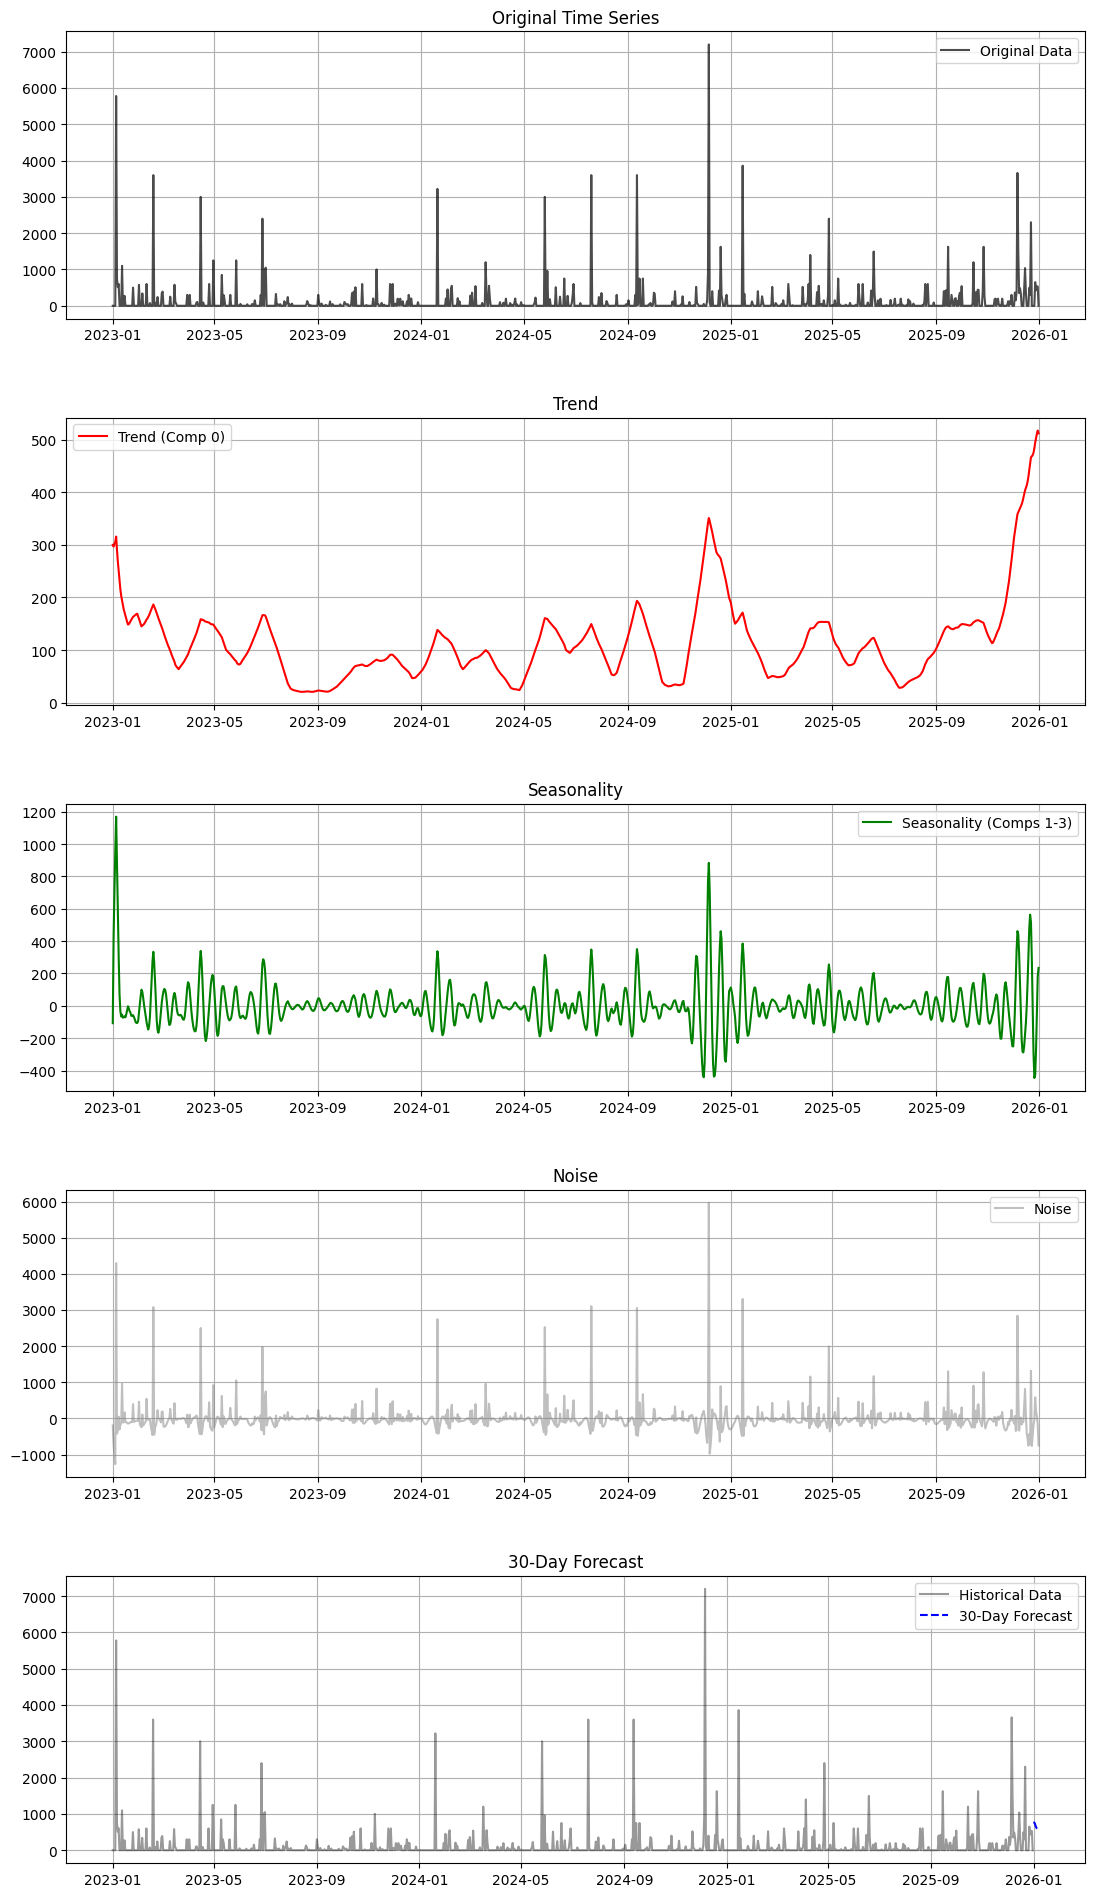

In [6]:
# Configuration
L = 30
steps_to_forecast = 7

# Initialize SSA
ssa = SSA(df['Value'], L=L)

# Extract components
trend = ssa.reconstruct(0)
seasonality = ssa.reconstruct([1, 2, 3])
noise = df['Value'] - trend - seasonality

# Forecast
forecast = ssa.forecast([0, 1, 2, 3], steps=steps_to_forecast)
forecast_dates = [df['Date'].iloc[-1] + datetime.timedelta(days=i) for i in range(1, steps_to_forecast + 1)]

# Store in DataFrame for convenience
df['Trend'] = trend
df['Seasonality'] = seasonality
df['Noise'] = noise

# Plotting
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
fig.tight_layout(pad=5.0)

# Original
axes[0].plot(df['Date'], df['Value'], label='Original Data', color='black', alpha=0.7)
axes[0].set_title('Original Time Series')
axes[0].legend()
axes[0].grid(True)

# Trend
axes[1].plot(df['Date'], df['Trend'], label='Trend (Comp 0)', color='red')
axes[1].set_title('Trend')
axes[1].legend()
axes[1].grid(True)

# Seasonality
axes[2].plot(df['Date'], df['Seasonality'], label='Seasonality (Comps 1-3)', color='green')
axes[2].set_title('Seasonality')
axes[2].legend()
axes[2].grid(True)

# Noise
axes[3].plot(df['Date'], df['Noise'], label='Noise', color='grey', alpha=0.5)
axes[3].set_title('Noise')
axes[3].legend()
axes[3].grid(True)

# Forecast
axes[4].plot(df['Date'], df['Value'], label='Historical Data', color='black', alpha=0.4)
axes[4].plot(forecast_dates, forecast, label='30-Day Forecast', color='blue', linestyle='--')
axes[4].set_title('30-Day Forecast')
axes[4].legend()
axes[4].grid(True)

# Save the figure before showing it
plt.savefig('daily_ssa_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 30-Day Forecast Values
Displaying the expected values for the next 30 days.

In [7]:
# Create a DataFrame for the 30-day forecast and display it
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast})
print(forecast_df.to_string(index=False))

      Date   Forecast
2026-01-01 775.699148
2026-01-02 761.416408
2026-01-03 700.824467
2026-01-04 637.817063
2026-01-05 597.353560
2026-01-06 573.988813
2026-01-07 547.714413
